In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
%matplotlib inline

**Contexto**

El conjunto de datos se compone de información recopilada de camiones pesados ​​Scania durante su uso cotidiano. El sistema objeto de estudio es el sistema de aire a presión (APS), el cual genera aire comprimido utilizado para diversas funciones del camión, tales como el frenado y el cambio de marchas. La clase positiva del conjunto de datos comprende los fallos de un componente específico del sistema APS, mientras que la clase negativa incluye camiones con fallos en componentes ajenos a dicho sistema.

El conjunto de entrenamiento contiene un total de 60.000 ejemplos, de los cuales 59.000 pertenecen a la clase negativa y 1.000 a la clase positiva. El conjunto de prueba contiene 16.000 ejemplos. Hay 171 atributos por registro.

Los nombres de los atributos de los datos han sido anonimizados por razones de propiedad. Estos consisten tanto en contadores numéricos individuales como en histogramas formados por intervalos (o *bins*) con diferentes condiciones. Por lo general, los histogramas presentan condiciones de rango abierto en ambos extremos. Por ejemplo, si se mide la temperatura ambiente "T", el histograma podría definirse con 4 intervalos donde:

Los atributos son los siguientes: la clase, seguida de datos operativos anonimizados. Los datos operativos cuentan con un identificador y un identificador de intervalo, con el formato "Identificador_Intervalo". En total hay 171 atributos, de los cuales 7 son variables de histograma. Los valores faltantes se indican mediante "na".

**Inspiración**

El costo total de un modelo de predicción es la suma del Costo_1 multiplicado por el número de instancias con fallas de tipo 1 y el Costo_2 multiplicado por el número de instancias con fallas de tipo 2, lo que resulta en un Costo_Total. En este caso, el Costo_1 se refiere al costo de una revisión innecesaria realizada por un mecánico en un taller, mientras que el Costo_2 se refiere al costo de no detectar un camión defectuoso, lo que podría causar una avería. Costo_1 = 10 y Costo_2 = 500, y Costo_Total = Costo_1 * Número_de_Instancias + Costo_2 * Número_de_Instancias.

In [2]:
train = pd.read_csv('aps_failure_training_set.csv', skiprows=20, na_values='na')
test = pd.read_csv('aps_failure_test_set.csv', skiprows=20, na_values='na')

In [3]:
train.shape

(60000, 171)

In [4]:
test.shape

(16000, 171)

### EDA

Descartamos la variable nula

In [5]:
from sklearn.impute import SimpleImputer

# cd_000 es constante (unico valor nulo) -> no aporta info, se descarta
train = train.drop(columns=['cd_000'])
test  = test.drop(columns=['cd_000'])

feature_cols = train.columns.drop('class')
imputer = SimpleImputer(strategy='median')
train[feature_cols] = imputer.fit_transform(train[feature_cols])
test[feature_cols] = imputer.transform(test[feature_cols])


In [6]:
train.shape

(60000, 170)

Verificamos las correlacion entre features del data set, para ver si hay correlacion fuerte entre algunas variables lo que nos permitiria eliminarlas. Tomamos un umbral de 0,9

In [7]:
threshold = 0.9

# corremos la correlacion sobre las variables continuas originales, sin 'class'
corr_matrix = train[feature_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# de cada par con |r| > threshold, nos quedamos con una y descartamos la otra
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print(f'Columnas eliminadas por alta correlacion (> {threshold}): {len(to_drop)} de {len(feature_cols)}')
print(to_drop)

train = train.drop(columns=to_drop)
test  = test.drop(columns=to_drop)

print('shape train:', train.shape, 'shape test:', test.shape)


Columnas eliminadas por alta correlacion (> 0.9): 43 de 169
['am_0', 'an_000', 'ao_000', 'aq_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'bb_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bt_000', 'bu_000', 'bv_000', 'by_000', 'cc_000', 'cf_000', 'ci_000', 'cn_004', 'cn_005', 'co_000', 'cq_000', 'cs_005', 'dc_000', 'dn_000', 'dp_000', 'dt_000', 'ed_000', 'ee_000', 'ee_001', 'ee_002', 'ee_003', 'ee_004']
shape train: (60000, 127) shape test: (16000, 127)


In [8]:
train.shape

(60000, 127)

In [9]:
test.shape

(16000, 127)

In [10]:
X_train_full = train.drop(columns='class')
y_train_full = train['class'].map({'neg': 0, 'pos': 1})

X_test = test.drop(columns='class')
y_test = test['class'].map({'neg': 0, 'pos': 1})


In [11]:
X_train_full.shape, y_train_full.shape, X_test.shape, y_test.shape

((60000, 126), (60000,), (16000, 126), (16000,))

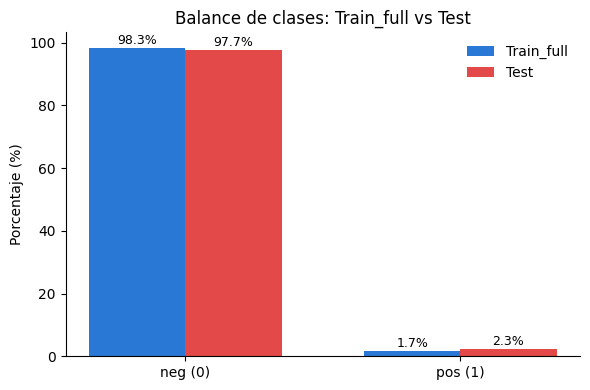

In [12]:
counts_train = y_train_full.value_counts(normalize=True).sort_index() * 100
counts_test  = y_test.value_counts(normalize=True).sort_index() * 100

labels = ['neg (0)', 'pos (1)']
x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars_train = ax.bar([i - width/2 for i in x], counts_train.values, width, label='Train_full', color='#2a78d6')
bars_test  = ax.bar([i + width/2 for i in x], counts_test.values, width, label='Test', color='#e34948')

ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Balance de clases: Train_full vs Test')
ax.legend(frameon=False)

for bars in [bars_train, bars_test]:
    for b in bars:
        height = b.get_height()
        ax.annotate(f'{height:.1f}%', xy=(b.get_x() + b.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Vamos a dividir el X_train_full y el y_train_full en un set de train y otro de validacion

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,  # importante por el desbalance
    random_state=42
)

In [14]:
X_train_full.shape, y_train_full.shape, X_train.shape, y_train.shape, X_val.shape, y_val.shape

((60000, 126), (60000,), (48000, 126), (48000,), (12000, 126), (12000,))

### Vamos a verificar cuales son las variables con mayor correlacion respecto del Target

aa_000    0.536978
ah_000    0.512991
bx_000    0.505529
ap_000    0.503651
ee_005    0.485831
ck_000    0.464198
ag_005    0.448212
cs_004    0.437519
ag_003    0.433050
az_005    0.432062
ba_000    0.430719
ee_006    0.415300
ay_008    0.409810
cn_003    0.406036
cs_003    0.391673
cn_001    0.390680
cs_002    0.372410
ag_004    0.371622
ag_006    0.368423
cn_002    0.367792
dtype: float64


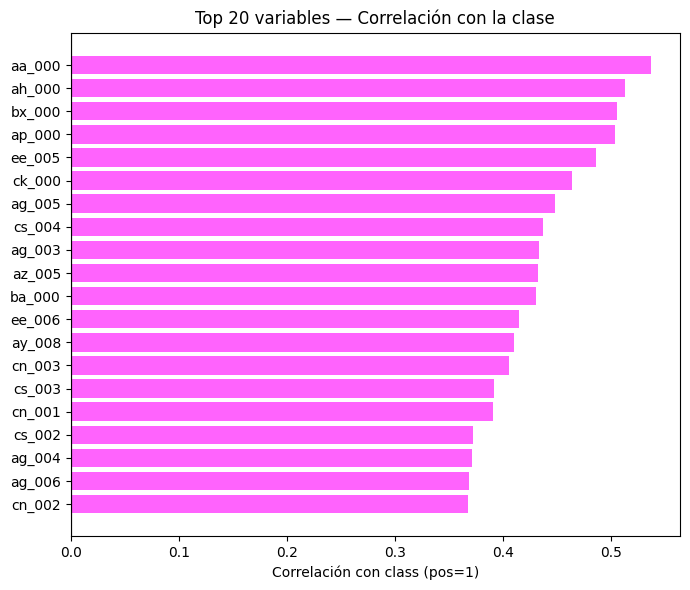

In [15]:
# correlación de cada variable con la clase (point-biserial, ya que la clase es binaria 0/1)
corr_class = X_train_full.corrwith(y_train_full).sort_values(key=lambda s: s.abs(), ascending=False)

top20_class = corr_class.head(20)
print(top20_class)

fig, ax = plt.subplots(figsize=(7, 6))
orden = top20_class.sort_values().index   # para que el gráfico quede ordenado de menor a mayor
valores = top20_class.loc[orden]
colores = ['#ff48fd' if v > 0 else '#007aff' for v in valores]
ax.barh(orden, valores, color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Correlación con class (pos=1)")
ax.set_title("Top 20 variables — Correlación con la clase")
plt.tight_layout()
plt.show()


### Vamos a aplicar un BASELINE con la variables de mayor correlacion con el target y tambien con las 5 variables que mejor correlacionan hacer una votacion 

In [16]:
# Baseline heurístico: umbral sobre aa_000 (variable con mayor correlación con la clase), sin entrenar ningún modelo
var_baseline = 'aa_000'

valor_neg = X_train.loc[y_train == 0, var_baseline]
valor_pos = X_train.loc[y_train == 1, var_baseline]
umbral_baseline = (valor_neg.median() + valor_pos.median()) / 2

y_pred_baseline = (X_test[var_baseline] > umbral_baseline).astype(int)


#### Definimos una funciona de costo

Como obervamos en el planteo original del problema, lo que se intenta identificar es MINIMIZAR LOS COSTOS DE MANTENIMIENTO PREVENTIVO. Para esto se utiliza los costos de Mantenimiento preventivo sin falla que es 10 y el costo de mantenimiento correctiva a la rotura que es 500.
Por lo tanto nuestro objetivo primordial es reducir los FN que serian fallas que van a ocurrir pero no se detectaron. Entonces definimos un costo = 10*FP+500*FN

In [24]:
def costo(y_true, y_pred):
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return fn * 500 + fp * 10


In [18]:
top5 = corr_class.abs().sort_values(ascending=False).head(5).index.tolist()

# umbral por variable: punto medio entre la mediana de la clase neg y la de la clase pos
umbrales_top5 = {}
for var in top5:
    valor_neg = X_train.loc[y_train == 0, var]
    valor_pos = X_train.loc[y_train == 1, var]
    umbrales_top5[var] = (valor_neg.median() + valor_pos.median()) / 2

print(umbrales_top5)

# para cada variable, 1 si supera su umbral, 0 si no
votos = pd.DataFrame({var: (X_test[var] > umbrales_top5[var]).astype(int) for var in top5})
conteo_votos = votos.sum(axis=1)

# predice falla si la mayoría (al menos 3 de 5) de las variables "alarman"
y_pred_baseline5 = (conteo_votos >= 3).astype(int)


{'aa_000': np.float64(300337.0), 'ah_000': np.float64(8957333.0), 'bx_000': np.float64(20649905.5), 'ap_000': np.float64(5375875.0), 'ee_005': np.float64(1432851.0)}


In [19]:
modelos = ["Baseline (umbral aa_000)", "Baseline (voto mayoría top5)"]
preds = [y_pred_baseline, y_pred_baseline5]

df_cmp = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds],
    "Costo": [costo(y_test, yp) for yp in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (umbral aa_000),0.5377,0.8635,0.4184,0.752,50420
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.808,39840


Como lo que se busca es **minimizar falsos negativos** podemos admitir tener una baja métrica de precisión en función de lograr una buena métrica de Recall o sensibilidad.

### Vamos a aplicar Regresion Logistica

##### Busqueda de hiperparametros

#### Funcion de costo

In [66]:
from sklearn.metrics import make_scorer

costo_scorer = make_scorer(costo, greater_is_better=False)


In [67]:
clf_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

hyperparams = {
    "model__C": [0.01, 0.1, 1],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced", {0: 1, 1: 50}]
}

grid = GridSearchCV(clf_logreg,
                    hyperparams,
                    refit=True,
                    cv=5,
                    scoring=costo_scorer,
                    n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)   # MB
inicio = time.perf_counter()

grid.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)  # MB

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid.best_params_)

Tiempo de búsqueda (GridSearchCV): 270.11 segundos
Memoria usada: 187.66 MB (antes: 145.63 MB, después: 333.29 MB)
{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}


In [68]:
grid.best_params_

{'model__C': 0.01,
 'model__class_weight': 'balanced',
 'model__penalty': 'l1',
 'model__solver': 'liblinear'}

Vemos que los hiperparámetros elegidos utilizan class_weight='balanced', para compensar el excesivo desbalance de los resultados. También usa regularización L1, que lo que hace es forzar muchos coeficientes a cero para anular variables que no aportan información. Además observamos que el valor de C es muy pequeño, lo que indica que la regularización es fuerte. Se utilizó el solver liblinear, que soporta regularización L1 y L2, y es el indicado para datasets chicos o medianos y para clasificación binaria.
También vemos que en el scoring se usó costo_scorer, que es una función que prioriza el costo de nuestro problema.

elegidos los parametros corremos el modelo

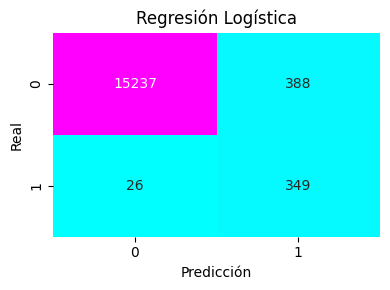

In [69]:
best_logreg = grid.best_estimator_

y_pred = best_logreg.predict(X_test)
cm_logreg = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Regresión Logística")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [70]:
TN, FP, FN, TP = cm_logreg.ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Regresión Logística")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Costo total = {FP * 10 + FN * 500:.0f} (FP: {FP}, FN: {FN})")

Regresión Logística
Sensibilidad (Recall): 0.9307
Especificidad:         0.9752
Exactitud balanceada:  0.9529
Precisión:             0.4735
Recall:                0.9307
F1-score:              0.6277
Costo total = 16880 (FP: 388, FN: 26)


In [72]:
# 1) Sacamos las probabilidades del modelo sobre la validación
#    predict_proba devuelve 2 columnas (prob de 0 y prob de 1), nos quedamos con la de clase 1 (pos)
probs = grid.best_estimator_.predict_proba(X_val)[:, 1]

# 2) Probamos distintos umbrales y calculamos el costo en cada uno
resultados = []

for umbral in np.arange(0.01, 1.00, 0.05):
    # convertimos probabilidad en predicción 0/1 según el umbral
    y_pred = (probs >= umbral).astype(int)
    
    # contamos falsos negativos y falsos positivos
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    
    # costo de negocio
    costo_i = fn * 500 + fp * 10
    
    resultados.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

# 3) Armamos una tabla para ver todo junto
tabla = pd.DataFrame(resultados)
print(tabla)

# 4) Nos quedamos con el umbral que minimiza el costo
mejor_fila = tabla.loc[tabla['costo'].idxmin()]
print("\nMejor umbral:")
print(mejor_fila)

    umbral  FN     FP   costo
0     0.01   0  11791  117910
1     0.06   1   4037   40870
2     0.11   5   1402   16520
3     0.16   5    892   11420
4     0.21   7    666   10160
5     0.26   7    552    9020
6     0.31   8    479    8790
7     0.36  10    432    9320
8     0.41  12    395    9950
9     0.46  12    359    9590
10    0.51  14    330   10300
11    0.56  16    299   10990
12    0.61  16    278   10780
13    0.66  19    251   12010
14    0.71  20    228   12280
15    0.76  22    210   13100
16    0.81  25    192   14420
17    0.86  28    174   15740
18    0.91  31    149   16990
19    0.96  41    111   21610

Mejor umbral:
umbral       0.31
FN           8.00
FP         479.00
costo     8790.00
Name: 6, dtype: float64


In [73]:
# 1) Sacamos las probabilidades del modelo sobre la validación
#    predict_proba devuelve 2 columnas (prob de 0 y prob de 1), nos quedamos con la de clase 1 (pos)
probs = grid.best_estimator_.predict_proba(X_val)[:, 1]

# 2) Probamos distintos umbrales y calculamos el costo en cada uno
resultados = []

for umbral in np.arange(0.26, 0.37, 0.01):
    # convertimos probabilidad en predicción 0/1 según el umbral
    y_pred = (probs >= umbral).astype(int)
    
    # contamos falsos negativos y falsos positivos
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    
    # costo de negocio
    costo_i = fn * 500 + fp * 10
    
    resultados.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

# 3) Armamos una tabla para ver todo junto
tabla = pd.DataFrame(resultados)
print(tabla)

# 4) Nos quedamos con el umbral que minimiza el costo
mejor_fila = tabla.loc[tabla['costo'].idxmin()]
print("\nMejor umbral:")
print(mejor_fila)

    umbral  FN   FP  costo
0     0.26   7  552   9020
1     0.27   7  535   8850
2     0.28   7  520   8700
3     0.29   7  508   8580
4     0.30   8  491   8910
5     0.31   8  479   8790
6     0.32  10  472   9720
7     0.33  10  458   9580
8     0.34  10  442   9420
9     0.35  10  437   9370
10    0.36  10  432   9320

Mejor umbral:
umbral       0.29
FN           7.00
FP         508.00
costo     8580.00
Name: 3, dtype: float64


In [74]:
probs_test = grid.best_estimator_.predict_proba(X_test)[:, 1]
umbral_final = 0.29
y_pred_test = (probs_test >= umbral_final).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
costo_final = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final en test: {costo_final}")
print(classification_report(y_test, y_pred_test, digits=3))

TN=14997, FP=628, FN=15, TP=360
Costo final en test: 13780
              precision    recall  f1-score   support

           0      0.999     0.960     0.979     15625
           1      0.364     0.960     0.528       375

    accuracy                          0.960     16000
   macro avg      0.682     0.960     0.754     16000
weighted avg      0.984     0.960     0.968     16000



Vamos a graficar una curva ROC del modelo

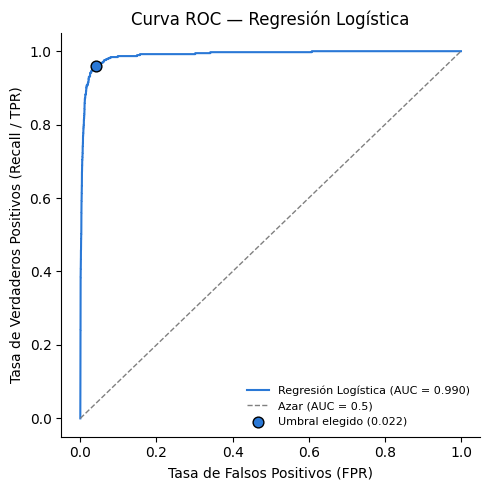

In [75]:
from sklearn.metrics import roc_curve, auc

fpr_log, tpr_log, _ = roc_curve(y_test, probs_test)
auc_log = auc(fpr_log, tpr_log)

tn_l, fp_l, fn_l, tp_l = confusion_matrix(y_test, y_pred_test).ravel()
fpr_op_log, tpr_op_log = fp_l / (fp_l + tn_l), tp_l / (tp_l + fn_l)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_log, tpr_log, color='#2a78d6', label=f'Regresión Logística (AUC = {auc_log:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_log], [tpr_op_log], color='#2a78d6', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.022)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Regresión Logística')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


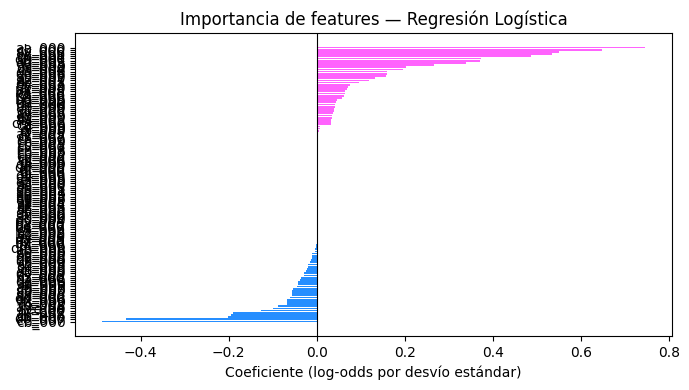

In [76]:
coefs = best_logreg.named_steps['model'].coef_.ravel()
orden = np.argsort(coefs)

fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#ff48fd' if c > 0 else '#007aff' for c in coefs[orden]]
feature_names = X_train.columns
ax.barh(np.array(feature_names)[orden], coefs[orden], color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Coeficiente (log-odds por desvío estándar)")
ax.set_title("Importancia de features — Regresión Logística")
plt.tight_layout()
plt.show()

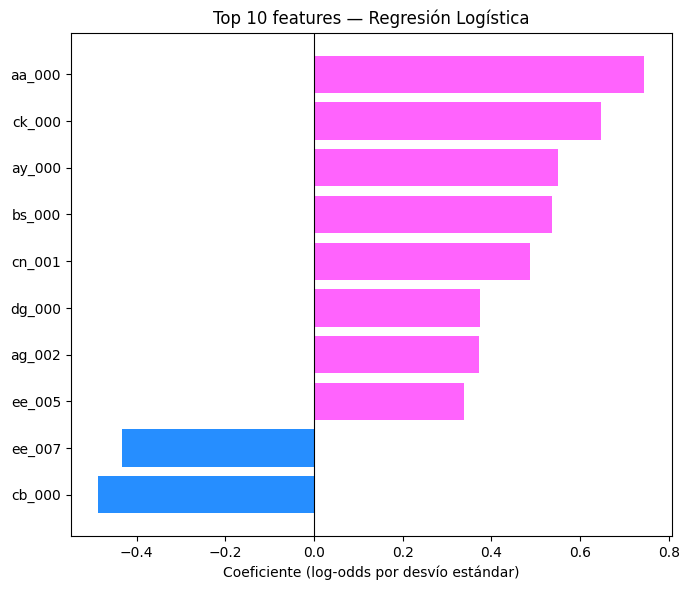

In [77]:
coefs = best_logreg.named_steps['model'].coef_.ravel()
feature_names = X_train.columns

n_top = 10
orden_abs = np.argsort(np.abs(coefs))[-n_top:]   # las n_top con mayor |coeficiente|
orden = orden_abs[np.argsort(coefs[orden_abs])]   # las reordena de menor a mayor para el gráfico

fig, ax = plt.subplots(figsize=(7, 6))
colores = ['#ff48fd' if c > 0 else '#007aff' for c in coefs[orden]]
ax.barh(np.array(feature_names)[orden], coefs[orden], color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Coeficiente (log-odds por desvío estándar)")
ax.set_title(f"Top {n_top} features — Regresión Logística")
plt.tight_layout()
plt.show()


Vemos una tabla de comparacion de modelos ejecutados

In [80]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)"]
preds_final = [y_pred_baseline5, y_pred_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.808,39840
Regresión Logística (umbral 0.29),0.5282,0.9599,0.3644,0.960,13780


Vemos que este modelo empeora la precisión pero mejora mucho la sensibilidad, lo cual es bueno en este problema ya que va a ser menor la cantidad de falsos negativos, que son los que más queremos evitar.

### Vamos a aplicar SVM

Antes de entrenar el data set completo y esto lleva mucho tiempo, vamos a realizar un muestreo del data set el con el cual vamos a seleccionar los hiperparametros a utilizar.

In [20]:
X_train_muestra, _, y_train_muestra, _ = train_test_split(
    X_train, y_train,
    train_size=8000,
    stratify=y_train,
    random_state=42
)


In [21]:
X_train_muestra.shape, y_train_muestra.shape

((8000, 126), (8000,))

Vamos a utilizar GridserachCV para la seleccion de hiperparametros

In [22]:
from sklearn.svm import SVC

clf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

hiper_svm = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", "auto"],   # se ignora automáticamente si kernel='linear'
    "model__class_weight": [None, "balanced"],
}

grid_svm = GridSearchCV(clf_svm,
                         hiper_svm,
                         refit=True,
                         cv=5,
                         scoring='f1',
                         n_jobs=-1)
grid_svm.fit(X_train_muestra, y_train_muestra)


,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'model__C': [0.1, 1, ...], 'model__class_weight': [None, 'balanced'], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['linear', 'rbf']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [23]:
print(grid_svm.best_params_)

{'model__C': 0.1, 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'linear'}


Obtenemos los mejores hiperparametrso calculados por el GridsearchCV, lo raro es que el 'model_class_weight':None, o sea no usa el balanceo de las variables a pesar de que esten muy desbalanceadas. Esto lo hace porque usa el scoring='f1', que fuerza a que de bien el valor de 'f1' en lugar del 'recall' que es el que nosotros quisieramos optimizar. Pero si pondriamos scoring='reacall' tambien nos daria muy mal porque el sistema forzaria  a que el recall de perfecto pero el resto de las clasificaciones darian muy mal. Ademas un punto a tener en cuenta que en todos los casoso el .predict() usa un umbral de 0,5 que para el caso nuestro que es un sistema muy desbalanceado nos juega en contra.
Lo que podemos hacer para mejorar la seleccion de hiperparametros es utilizar una funcion de costo, que es lo que que define el objetivo de nuestro problemas, minimizar el costo total de mantenimiento, lo cual penaliza muchisimos si tiene muchhos FN y que el costo de los mismos es 50 veces mas caro que un FP

Se agrega la funcion make_scorer que esto le permite a la busqueda de hiperparametros que mejan el costo del problema, que es minimizarlo, en lugar de utilizar alguna metrica especifica.

In [26]:
from sklearn.metrics import make_scorer

costo_scorer = make_scorer(costo, greater_is_better=False)

clf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

hiper_svm = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.05, 0.1, 0.2],
    "model__gamma": ["scale", "auto"],   # se ignora automáticamente si kernel='linear'
    "model__class_weight": ["balanced"],
}


grid_svm = GridSearchCV(clf_svm,
                         hiper_svm,
                         refit=True,
                         cv=5,
                         scoring=costo_scorer,
                         n_jobs=-1)
grid_svm.fit(X_train_muestra, y_train_muestra)


,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'model__C': [0.05, 0.1, ...], 'model__class_weight': ['balanced'], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['linear', 'rbf']}"
,scoring,make_scorer(c...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [115]:
grid_svm.best_params_

{'model__C': 0.1,
 'model__class_weight': 'balanced',
 'model__gamma': 'scale',
 'model__kernel': 'rbf'}

Ahora con esta seleccion de hiperparametros vamos a correr el train del modelo completo, pero agregando el probability=True, los que no va a dar el resultado probable de cada seleccion. Como en el el entrenamiento utiliza .predict() el umbral de 0,5 nosotros con el set de validacion vamos a probar cambiar estos valores para ver si mejora la performance  del modelo

Vamos a agregar codigo tambien para medir el tiempo utilizado en el entrenamiento y el costo de computo utilizado

In [27]:
clf_svm_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(C=0.1, kernel='rbf', gamma='scale', class_weight='balanced', probability=True, random_state=42))
])



In [28]:
import time
import psutil
import os

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)   # MB
inicio = time.perf_counter()

clf_svm_final.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)  # MB

print(f"Tiempo de entrenamiento: {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")


Tiempo de entrenamiento: 346.33 segundos
Memoria usada: -49.04 MB (antes: 425.68 MB, después: 376.65 MB)


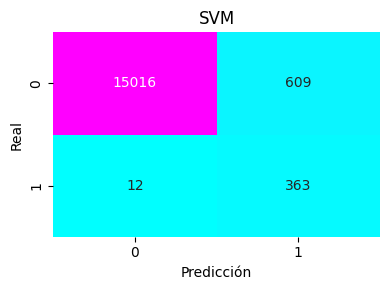

SVM (umbral 0.5, sin ajustar)
Sensibilidad (Recall): 0.9680
Especificidad:         0.9610
Exactitud balanceada:  0.9645
Precisión:             0.3735
Recall:                0.9680
F1-score:              0.5390
Costo total = 12090 (FP: 609, FN: 12)


In [29]:
y_pred_svm = clf_svm_final.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("SVM")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_svm.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("SVM (umbral 0.5, sin ajustar)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"Costo total = {costo(y_test, y_pred_svm)} (FP: {FP}, FN: {FN})")


Ahora vamos a probar ajustar el umbal de 0,5 a ver si mejora incluso mas el ajuste para optimizar el costo. Esta prueba la vamos a hacer con paquete de validacion.

In [30]:
probs_svm = clf_svm_final.predict_proba(X_val)[:, 1]

resultados_svm = []
for umbral in np.arange(0.05, 1.00, 0.05):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_svm = pd.DataFrame(resultados_svm)
print(tabla_svm)

mejor_fila_svm = tabla_svm.loc[tabla_svm['costo'].idxmin()]
print("\nMejor umbral SVM (barrido grueso):")
print(mejor_fila_svm)


    umbral   FN   FP  costo
0     0.05    8  451   8510
1     0.10    9  382   8320
2     0.15   11  319   8690
3     0.20   11  283   8330
4     0.25   13  245   8950
5     0.30   17  192  10420
6     0.35   87   73  44230
7     0.40  124   48  62480
8     0.45  142   38  71380
9     0.50  175   33  87830
10    0.55  180   29  90290
11    0.60  183   21  91710
12    0.65  188   20  94200
13    0.70  189   18  94680
14    0.75  192   12  96120
15    0.80  193    9  96590
16    0.85  194    5  97050
17    0.90  196    3  98030
18    0.95  198    1  99010

Mejor umbral SVM (barrido grueso):
umbral       0.1
FN           9.0
FP         382.0
costo     8320.0
Name: 1, dtype: float64


Queremos hacer zoom en el umbral 0,35 que cae de golpe los FN a pesar que no es el punto de menor costo hay alguno evento que ocurre que fallen muchos camiones en ese punto.

In [31]:
resultados_svm_zoom = []
for umbral in np.arange(0.25, 0.36, 0.01):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm_zoom.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

pd.DataFrame(resultados_svm_zoom)


,umbral,FN,FP,costo
0,0.25,13,245,8950
1,0.26,13,238,8880
2,0.27,15,229,9790
3,0.28,16,219,10190
4,0.29,16,204,10040
5,0.30,17,192,10420
6,0.31,18,179,10790
7,0.32,19,168,11180
8,0.33,21,161,12110
9,0.34,27,140,14900


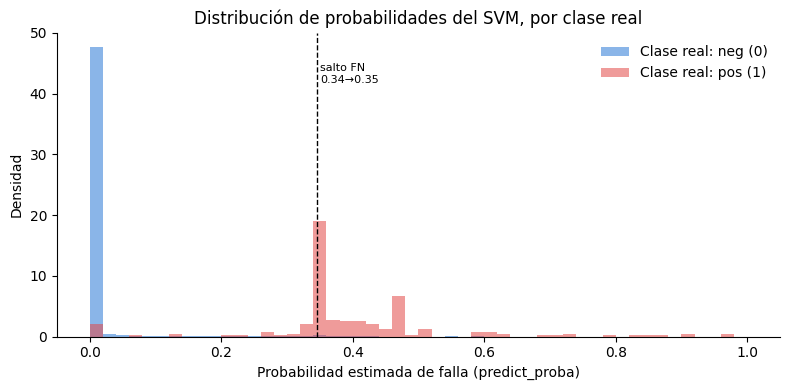

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

bins = np.arange(0, 1.02, 0.02)

ax.hist(probs_svm[y_val == 0], bins=bins, density=True, alpha=0.55,
        color='#2a78d6', label='Clase real: neg (0)')
ax.hist(probs_svm[y_val == 1], bins=bins, density=True, alpha=0.55,
        color='#e34948', label='Clase real: pos (1)')

ax.axvline(0.345, color='k', linestyle='--', linewidth=1)
ax.text(0.35, ax.get_ylim()[1]*0.9, 'salto FN\n0.34→0.35', fontsize=8, va='top')

ax.set_xlabel('Probabilidad estimada de falla (predict_proba)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidades del SVM, por clase real')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

En el grafico se muesta lo que creiamos ese umbral de probabilidades ocurre algun evento/os en particular que hace que muchos camiones fallen.

Ahora vamos a afinar los umbrales para ver si podemos mejorar el desempeño del costo

In [33]:
resultados_svm_fino = []
for umbral in np.arange(0.05, 0.21, 0.01):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm_fino.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_svm_fino = pd.DataFrame(resultados_svm_fino)
print(tabla_svm_fino)

mejor_fila_svm_fino = tabla_svm_fino.loc[tabla_svm_fino['costo'].idxmin()]
print("\nMejor umbral SVM (barrido fino):")
print(mejor_fila_svm_fino)


    umbral  FN   FP  costo
0     0.05   8  451   8510
1     0.06   8  429   8290
2     0.07   9  411   8610
3     0.08   9  397   8470
4     0.09   9  391   8410
5     0.10   9  382   8320
6     0.11   9  368   8180
7     0.12   9  356   8060
8     0.13  10  345   8450
9     0.14  11  330   8800
10    0.15  11  319   8690
11    0.16  11  311   8610
12    0.17  11  307   8570
13    0.18  11  298   8480
14    0.19  11  292   8420
15    0.20  11  283   8330

Mejor umbral SVM (barrido fino):
umbral       0.12
FN           9.00
FP         356.00
costo     8060.00
Name: 7, dtype: float64


Con el mejor umbral seleccionado ahora lo corremos contra el paquete de test

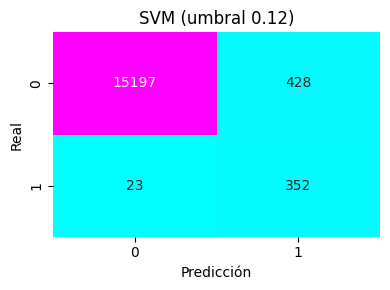

TN=15197, FP=428, FN=23, TP=352
Costo final SVM en test: 15780
              precision    recall  f1-score   support

           0      0.998     0.973     0.985     15625
           1      0.451     0.939     0.610       375

    accuracy                          0.972     16000
   macro avg      0.725     0.956     0.797     16000
weighted avg      0.986     0.972     0.977     16000



In [48]:
probs_svm_test = clf_svm_final.predict_proba(X_test)[:, 1]
umbral_final_svm = 0.12
y_pred_svm_test = (probs_svm_test >= umbral_final_svm).astype(int)

cm_svm_test = confusion_matrix(y_test, y_pred_svm_test)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_svm_test, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("SVM (umbral 0.12)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_svm_test.ravel()
costo_final_svm = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final SVM en test: {costo_final_svm}")
print(classification_report(y_test, y_pred_svm_test, digits=3))



Por ultimo graficamos la curva ROC del modelo

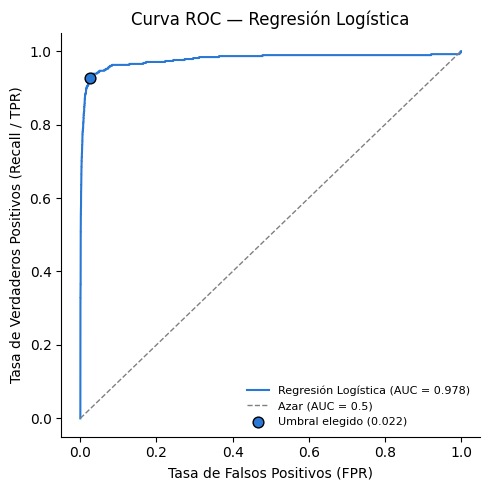

In [54]:
from sklearn.metrics import roc_curve, auc

fpr_log, tpr_log, _ = roc_curve(y_test, probs_test)
auc_log = auc(fpr_log, tpr_log)

tn_l, fp_l, fn_l, tp_l = confusion_matrix(y_test, y_pred_test).ravel()
fpr_op_log, tpr_op_log = fp_l / (fp_l + tn_l), tp_l / (tp_l + fn_l)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_log, tpr_log, color='#2a78d6', label=f'Regresión Logística (AUC = {auc_log:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_log], [tpr_op_log], color='#2a78d6', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.022)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Regresión Logística')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Ahora vamos a hacer una comparación de los modelos que se fueron utilizando

In [81]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)", "SVM (umbral 0.12)"]
preds_final = [y_pred_baseline5, y_pred_test, y_pred_svm_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.8080,39840
Regresión Logística (umbral 0.29),0.5282,0.9599,0.3644,0.9600,13780
SVM (umbral 0.12),0.6095,0.9556,0.4513,0.9387,15780


Conclusión de porque nosotros no necesitamos calibrar nuestro modelo. Como el objetivo que nosotros buscamos es optimizar la funcion de costo, el valor de predict_proba que nosotros movemos es para optimizar el corte de nuestro modelo y mejorar la clasificacion. Y basicamente no usamos en ninguna caso el predict_proba como una magnitud en si misma, por ejemplo "estimar el porcentaje de la flota que va a fallar", en ese caso si deberiamos calibrar el valor.
En ambos casos la calibracion es mala porque en ambos modelos se utilizo la funcion costo_scorer y ademas se utilizo class_weight='balanced' y esto hace rque el modelo entrene como si las clases eruvieran mas equilibradas de lo que lo estan realmente.

Graficamos las curvas de calibracion de ambos modelos, solo para observarlas pero en nuestro caso no es de utilidad para nuestro problema.

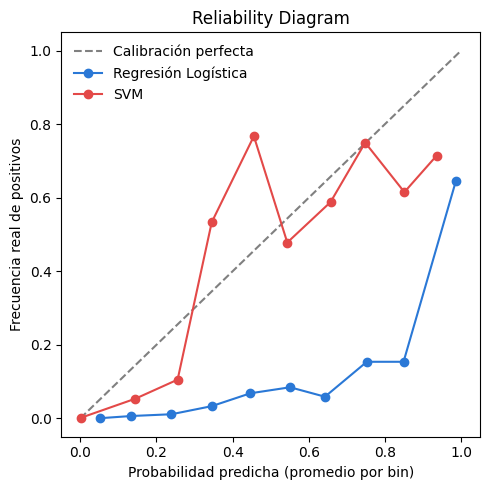

Brier score logreg: 0.024890377866583355
Brier score SVM: 0.012452035217399782


In [84]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

frac_pos_log, mean_pred_log = calibration_curve(y_test, probs_test, n_bins=10)
frac_pos_svm, mean_pred_svm = calibration_curve(y_test, probs_svm_test, n_bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Calibración perfecta')
ax.plot(mean_pred_log, frac_pos_log, marker='o', color='#2a78d6', label='Regresión Logística')
ax.plot(mean_pred_svm, frac_pos_svm, marker='o', color='#e34948', label='SVM')
ax.set_xlabel('Probabilidad predicha (promedio por bin)')
ax.set_ylabel('Frecuencia real de positivos')
ax.set_title('Reliability Diagram')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Brier score logreg:", brier_score_loss(y_test, probs_test))
print("Brier score SVM:", brier_score_loss(y_test, probs_svm_test))

#### Arboles de clasificacion

En este tipo de modelo no necesitamos escalar los valores de los features. Asi que vamos a hacer una seleccion de hiperparametros con GridsearchCV para seleccionar los mejores hiperparametros

Como vemos la funcion de scoring vamos a usar nuevamente la funcion de costo de nuestro problema.

In [58]:
from sklearn.tree import DecisionTreeClassifier

hiper_tree = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": [None, "balanced"],
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          hiper_tree,
                          refit=True,
                          cv=5,
                          scoring=costo_scorer,
                          n_jobs=-1)
grid_tree.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,scoring,make_scorer(c...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [59]:
grid_tree.best_params_


{'class_weight': 'balanced',
 'max_depth': 3,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

Vamos a volver a entrenar los parametros ya que max_depth quedo en el valor minio de 3 que era lo que habiamos puestos como piso de profundidad. Tambien agregamos a script para medir tiempo y memoria utilizada para la seleccion de hiperparametros

In [60]:

hiper_tree = {
    "max_depth": [1, 2, 3, 4, 5],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": [None, "balanced"],
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          hiper_tree,
                          refit=True,
                          cv=5,
                          scoring=costo_scorer,
                          n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)   # MB
inicio = time.perf_counter()

grid_tree.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)  # MB

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_tree.best_params_)


Tiempo de búsqueda (GridSearchCV): 103.78 segundos
Memoria usada: 0.36 MB (antes: 188.48 MB, después: 188.84 MB)
{'class_weight': 'balanced', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}


Vamos a entrenar el paquete de test y ver los resultados obtenidos

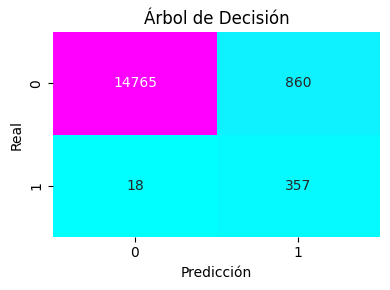

Árbol de Decisión (umbral 0.5, sin ajustar)
Sensibilidad (Recall): 0.9520
Especificidad:         0.9450
Exactitud balanceada:  0.9485
Precisión:             0.2933
Recall:                0.9520
F1-score:              0.4485
Costo total = 17600 (FP: 860, FN: 18)


In [61]:
best_tree = grid_tree.best_estimator_

y_pred_tree = best_tree.predict(X_test)
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Árbol de Decisión")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_tree.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Árbol de Decisión (umbral 0.5, sin ajustar)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred_tree, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred_tree, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred_tree, zero_division=0):.4f}")
print(f"Costo total = {costo(y_test, y_pred_tree)} (FP: {FP}, FN: {FN})")


Vamos a utilzar el set de validacion para verificar cual umbral de p_proba mejora el trade off para la funciona de costo que tenemos

In [62]:
probs_tree = best_tree.predict_proba(X_val)[:, 1]
print(f"Valores distintos de probabilidad: {np.unique(probs_tree)}")

resultados_tree = []
for umbral in np.arange(0.05, 1.00, 0.05):
    y_pred = (probs_tree >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_tree.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_tree = pd.DataFrame(resultados_tree)
print(tabla_tree)

mejor_fila_tree = tabla_tree.loc[tabla_tree['costo'].idxmin()]
print("\nMejor umbral árbol:")
print(mejor_fila_tree)


Valores distintos de probabilidad: [0.         0.01930673 0.15580986 0.19281046 0.25877193 0.53881279
 0.76623377 0.80902518 0.84841222 0.92367906 0.9661957  0.97520661]
    umbral  FN    FP  costo
0     0.05   6  1044  13440
1     0.10   6  1044  13440
2     0.15   6  1044  13440
3     0.20   8   747  11470
4     0.25   8   747  11470
5     0.30   8   699  10990
6     0.35   8   699  10990
7     0.40   8   699  10990
8     0.45   8   699  10990
9     0.50   8   699  10990
10    0.55   8   675  10750
11    0.60   8   675  10750
12    0.65   8   675  10750
13    0.70   8   675  10750
14    0.75   8   675  10750
15    0.80   8   659  10590
16    0.85  25   389  16390
17    0.90  25   389  16390
18    0.95  25   373  16230

Mejor umbral árbol:
umbral        0.8
FN            8.0
FP          659.0
costo     10590.0
Name: 15, dtype: float64


Ahora vamos a correr el data set de test con p_proba modificado el umbal a 0,8

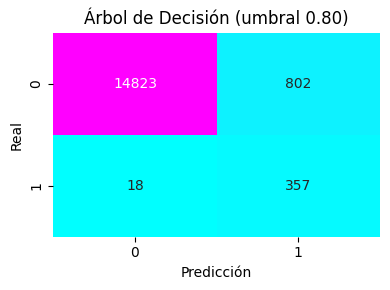

TN=14823, FP=802, FN=18, TP=357
Costo final árbol en test: 17020
              precision    recall  f1-score   support

           0      0.999     0.949     0.973     15625
           1      0.308     0.952     0.465       375

    accuracy                          0.949     16000
   macro avg      0.653     0.950     0.719     16000
weighted avg      0.983     0.949     0.961     16000



In [63]:
probs_tree_test = best_tree.predict_proba(X_test)[:, 1]
umbral_final_tree = 0.80
y_pred_tree_test = (probs_tree_test >= umbral_final_tree).astype(int)

cm_tree_test = confusion_matrix(y_test, y_pred_tree_test)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_tree_test, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Árbol de Decisión (umbral 0.80)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_tree_test.ravel()
costo_final_tree = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final árbol en test: {costo_final_tree}")
print(classification_report(y_test, y_pred_tree_test, digits=3))


Vamos a graficar la curva ROC

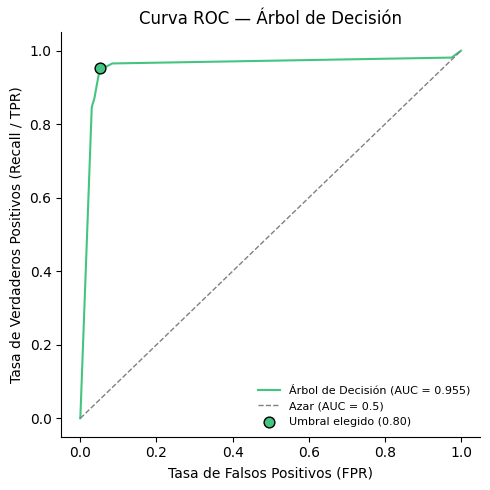

In [64]:
fpr_tree, tpr_tree, _ = roc_curve(y_test, probs_tree_test)
auc_tree = auc(fpr_tree, tpr_tree)

tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_tree_test).ravel()
fpr_op_tree, tpr_op_tree = fp_t / (fp_t + tn_t), tp_t / (tp_t + fn_t)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_tree, tpr_tree, color='#44c57f', label=f'Árbol de Decisión (AUC = {auc_tree:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_tree], [tpr_op_tree], color='#44c57f', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.80)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Árbol de Decisión')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Por ultimo agregamos una tabla comparativa

In [83]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)", "SVM (umbral 0.12)", "Árbol de Decisión (umbral 0.80)"]
preds_final = [y_pred_baseline5, y_pred_test, y_pred_svm_test, y_pred_tree_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.8080,39840
Regresión Logística (umbral 0.29),0.5282,0.9599,0.3644,0.9600,13780
SVM (umbral 0.12),0.6095,0.9556,0.4513,0.9387,15780
Árbol de Decisión (umbral 0.80),0.4654,0.9503,0.3080,0.9520,17020


#### Random Forest

Vamos a seleccionar los hiperparametos para este modelo

In [85]:
from sklearn.ensemble import RandomForestClassifier

hiper_rf = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [1, 5],
    "class_weight": [None, "balanced", "balanced_subsample"],
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                        hiper_rf,
                        refit=True,
                        cv=5,
                        scoring=costo_scorer,
                        n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)
inicio = time.perf_counter()

grid_rf.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_rf.best_params_)


Tiempo de búsqueda (GridSearchCV): 940.05 segundos
Memoria usada: 55.30 MB (antes: 153.91 MB, después: 209.21 MB)
{'class_weight': 'balanced', 'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 100}


Como varios hiperparametros cayeron en los bordes de las opciones de prueba. Vamos a correrlo de nuevos con nuevos valores de hiperparametros, solo vamos a dejar fijo el class_weight+'balanced' que ya quedo definido.

In [86]:
hiper_rf_v2 = {
    "n_estimators": [50, 100, 150],
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [5, 10],
    "class_weight": ["balanced"],
}

grid_rf_v2 = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=1),
                           hiper_rf_v2,
                           refit=True,
                           cv=5,
                           scoring=costo_scorer,
                           n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)
inicio = time.perf_counter()

grid_rf_v2.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_rf_v2.best_params_)


Tiempo de búsqueda (GridSearchCV): 203.51 segundos
Memoria usada: -4.59 MB (antes: 200.80 MB, después: 196.21 MB)
{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 150}


In [87]:
hiper_rf_v3 = {
    "n_estimators": [150, 200, 300],
    "max_depth": [5, 6, 8, 10],
    "min_samples_leaf": [10, 15, 20],
    "class_weight": ["balanced"],
}

grid_rf_v3 = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=1),
                           hiper_rf_v3,
                           refit=True,
                           cv=5,
                           scoring=costo_scorer,
                           n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)
inicio = time.perf_counter()

grid_rf_v3.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_rf_v3.best_params_)


Tiempo de búsqueda (GridSearchCV): 912.51 segundos
Memoria usada: 3.04 MB (antes: 179.09 MB, después: 182.13 MB)
{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 150}


"Vamos a analizar los hiperparámetros seleccionados. class_weight='balanced', al igual que en todos los modelos, se utiliza para compensar el excesivo desbalance que tiene nuestro set de datos. Con max_depth=5 vemos que el modelo no necesita mucha profundidad para capturar la separación de resultados. El min_samples_leaf=10 es bastante restrictivo, evita que los árboles creen hojas muy específicas. n_estimators=150 es una cantidad de árboles intermedia, no muy chica pero tampoco excesivamente grande (lo cual implicaría un costo computacional mayor). También usamos scoring=costo_scorer, que es nuestra función de costo del problema."

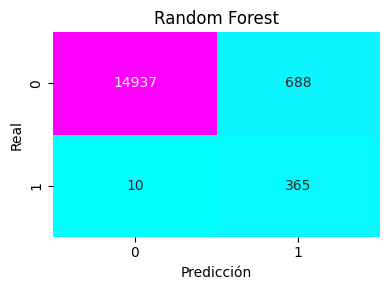

Random Forest (umbral 0.5, sin ajustar)
Sensibilidad (Recall): 0.9733
Especificidad:         0.9560
Exactitud balanceada:  0.9647
Precisión:             0.3466
Recall:                0.9733
F1-score:              0.5112
Costo total = 11880 (FP: 688, FN: 10)


In [88]:
best_rf = grid_rf_v3.best_estimator_

y_pred_rf = best_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Random Forest")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_rf.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Random Forest (umbral 0.5, sin ajustar)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Costo total = {costo(y_test, y_pred_rf)} (FP: {FP}, FN: {FN})")


In [89]:
probs_rf = best_rf.predict_proba(X_val)[:, 1]

resultados_rf = []
for umbral in np.arange(0.01, 1.00, 0.05):
    y_pred = (probs_rf >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_rf.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_rf = pd.DataFrame(resultados_rf)
print(tabla_rf)

mejor_fila_rf = tabla_rf.loc[tabla_rf['costo'].idxmin()]
print("\nMejor umbral Random Forest (barrido amplio):")
print(mejor_fila_rf)


    umbral   FN     FP   costo
0     0.01    0  11800  118000
1     0.06    2   1888   19880
2     0.11    2   1330   14300
3     0.16    2   1099   11990
4     0.21    4    980   11800
5     0.26    4    876   10760
6     0.31    5    806   10560
7     0.36    5    731    9810
8     0.41    5    662    9120
9     0.46    6    610    9100
10    0.51    7    555    9050
11    0.56   10    506   10060
12    0.61   10    440    9400
13    0.66   13    399   10490
14    0.71   19    354   13040
15    0.76   26    305   16050
16    0.81   33    240   18900
17    0.86   44    181   23810
18    0.91   77    110   39600
19    0.96  122     21   61210

Mejor umbral Random Forest (barrido amplio):
umbral       0.51
FN           7.00
FP         555.00
costo     9050.00
Name: 10, dtype: float64


In [90]:
resultados_rf_fino = []
for umbral in np.arange(0.41, 0.62, 0.01):
    y_pred = (probs_rf >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_rf_fino.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_rf_fino = pd.DataFrame(resultados_rf_fino)
print(tabla_rf_fino)

mejor_fila_rf_fino = tabla_rf_fino.loc[tabla_rf_fino['costo'].idxmin()]
print("\nMejor umbral Random Forest (barrido fino):")
print(mejor_fila_rf_fino)


    umbral  FN   FP  costo
0     0.41   5  662   9120
1     0.42   5  646   8960
2     0.43   5  636   8860
3     0.44   6  628   9280
4     0.45   6  621   9210
5     0.46   6  610   9100
6     0.47   6  597   8970
7     0.48   6  587   8870
8     0.49   6  576   8760
9     0.50   6  565   8650
10    0.51   7  555   9050
11    0.52   7  546   8960
12    0.53   9  531   9810
13    0.54  10  526  10260
14    0.55  10  519  10190
15    0.56  10  506  10060
16    0.57  10  488   9880
17    0.58  10  471   9710
18    0.59  10  459   9590
19    0.60  10  447   9470
20    0.61  10  440   9400

Mejor umbral Random Forest (barrido fino):
umbral       0.5
FN           6.0
FP         565.0
costo     8650.0
Name: 9, dtype: float64


Un dato importante para destacar es que el umbral que mejor costo nos da haciendo el ajuste fino es el umbral que el modelo toma por defecto en 0,5.

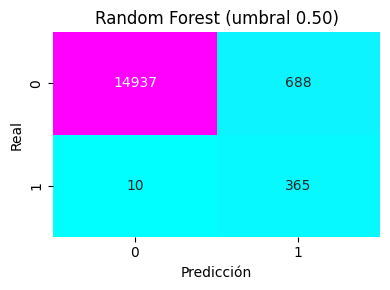

TN=14937, FP=688, FN=10, TP=365
Costo final Random Forest en test: 11880
              precision    recall  f1-score   support

           0      0.999     0.956     0.977     15625
           1      0.347     0.973     0.511       375

    accuracy                          0.956     16000
   macro avg      0.673     0.965     0.744     16000
weighted avg      0.984     0.956     0.966     16000



In [91]:
probs_rf_test = best_rf.predict_proba(X_test)[:, 1]
umbral_final_rf = 0.50
y_pred_rf_test = (probs_rf_test >= umbral_final_rf).astype(int)

cm_rf_test = confusion_matrix(y_test, y_pred_rf_test)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_rf_test, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Random Forest (umbral 0.50)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf_test.ravel()
costo_final_rf = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final Random Forest en test: {costo_final_rf}")
print(classification_report(y_test, y_pred_rf_test, digits=3))


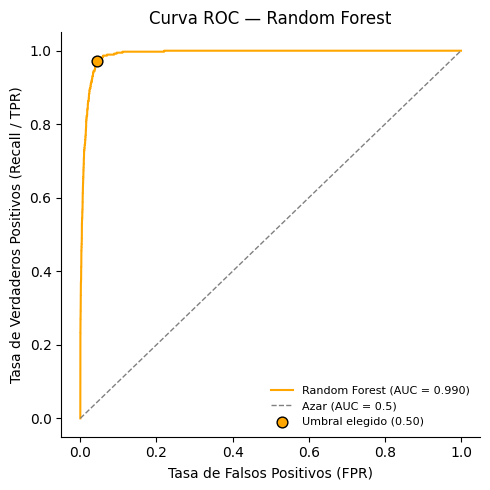

In [92]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf_test)
auc_rf = auc(fpr_rf, tpr_rf)

tn_r, fp_r, fn_r, tp_r = confusion_matrix(y_test, y_pred_rf_test).ravel()
fpr_op_rf, tpr_op_rf = fp_r / (fp_r + tn_r), tp_r / (tp_r + fn_r)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_rf, tpr_rf, color='#ffa600', label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_rf], [tpr_op_rf], color='#ffa600', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.50)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Random Forest')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Vamos a realizar un grafico para observar cuales son las features que mayor informacion le aportan al modelo random forest clasificar si un camion va a fallar.

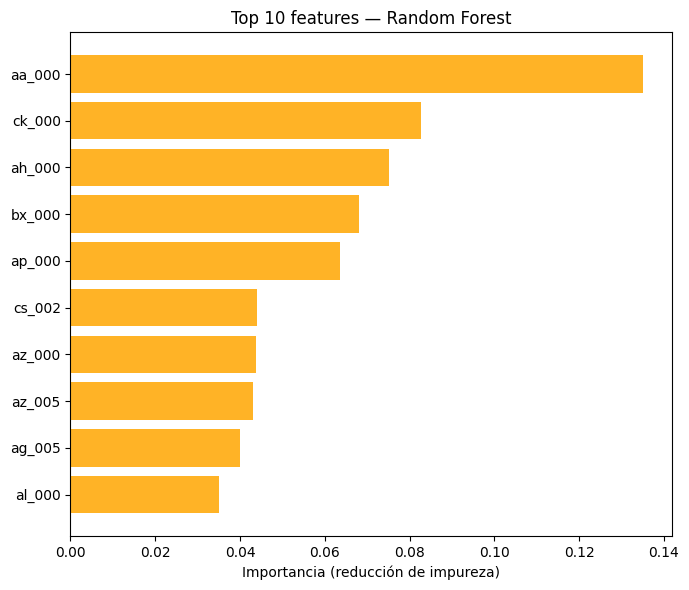

In [93]:
importancias = best_rf.feature_importances_
feature_names = X_train.columns

n_top = 10
orden = np.argsort(importancias)[-n_top:]   # las n_top con mayor importancia

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(np.array(feature_names)[orden], importancias[orden], color='#ffa600', alpha=0.85)
ax.set_xlabel("Importancia (reducción de impureza)")
ax.set_title(f"Top {n_top} features — Random Forest")
plt.tight_layout()
plt.show()


Observamos que 8 de las 10 variables se corresponden con las que mayor correlacion tienen con el target. Y vemos otras 2 variables que no tienen realación monotona con el target seguramente en combinacion con otras variables aportan mas valor para la clasificacion

### Por utlimo vamos a ver un cuadro comparativo de todos los modelos entrenados

In [94]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)", "SVM (umbral 0.12)", "Árbol de Decisión (umbral 0.80)", "Random Forest (umbral 0.50)"]
preds_final = [y_pred_baseline5, y_pred_test, y_pred_svm_test, y_pred_tree_test, y_pred_rf_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.8080,39840
Regresión Logística (umbral 0.29),0.5282,0.9599,0.3644,0.9600,13780
SVM (umbral 0.12),0.6095,0.9556,0.4513,0.9387,15780
Árbol de Decisión (umbral 0.80),0.4654,0.9503,0.3080,0.9520,17020
Random Forest (umbral 0.50),0.5112,0.9647,0.3466,0.9733,11880


##### Conclusión de resultados:
Vemos que el modelo que mejor performa según nuestro objetivo primordial, que es minimizar el costo, es Random Forest, con un costo de 11.880, y como segundo modelo que mejor performa está Regresión Logística, con un costo de 13.780.

Al observar los resultados vemos que los F1-score dan valores muy bajos, ya que detectar un Falso Positivo no resulta muy costoso para la función de costo. Respecto a la exactitud balanceada, a pesar de no tener en cuenta la función de costo, nos da un buen indicador: el mejor valor lo tiene Random Forest, lo cual nos dice que el modelo tiene una buena relación (sensibilidad + especificidad)/2. Y el Recall, obviamente, también es mejor en Random Forest, ya que tiene muy en cuenta los Falsos Negativos, que son los que mayor costo tienen en la función de costo que es nuestro objetivo.

Creemos que a pesar de haber trabajado con un dataset desbalanceado se logró encontrar la manera de entrenar un modelo que sea útil para el problema en cuestión. En nuestro caso expresamente fue no dejar pasar Falsos Negativos ya que esto implicaría un sistema con falla que termina llegando a mantenimiento luego de haber fallado (no logra llegar al mantenimiento preventivamente).

Entendemos este caso como uno en donde la aplicación de la IA puede efectivamente generar un ahorro de dinero en una empresa, ya que hará que muchos camiones puedan llegar a tener mantenimiento preventivo antes de fallar y finalmente reducir las pérdidas económicas de la empresa.